# Exploratory Data Analysis — ChurnGuard
**Objectif** : Explorer les données brutes pour comprendre leur structure, 
détecter les anomalies et identifier les patterns liés au churn de la Banque.

**Dataset** : `churn_dataset_messy.csv`  
**Auteur** : Romaric TCHOFFO  
**Date** : 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

df  = pd.read_csv("../data/raw/churn_dataset_messy.csv")

print("import des modules et Dataset chargé")

import des modules et Dataset chargé


## 1.Aperçu général

In [2]:
df.head()

,ID,CustomerID,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,RegistrationDate,SatisfactionScore,NumComplaints,Email,Exited
0,111819,82197283105,Johnson,567.0,Germany,Homme,38,8.0,5234.53,2.0,1,1,0,2021-11-05,4,0.0,diane30@example.net,1
1,101210,36912803096,Lawrence,894.0,Spain,Male,54,3.0,13629.78,3.0,1,0,113027.18,2011-05-26,4,0.0,gordonosullivan@example.com,0
2,109466,97155583156,Chevalier,788.0,Spain,Male,40,9.0,17123.43,1.0,1,0,96117.51,2020-11-27,2,0.0,monniersylvie@example.org,0
3,104337,26159789757,Mülichen,608.0,Spain,Male,36,9.0,128278.02,1.0,1,1,81814.93,2015-10-28,4,2.0,derekstewart@example.org,0
4,112467,54492422739,Thomas,714.0,France,Male,25,1.0,7729.62,1.0,0,1,41672.29,2019-01-08,4,0.0,email@,0


In [3]:
df.shape

(15750, 18)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15750 entries, 0 to 15749
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 15750 non-null  int64  
 1   CustomerID         15750 non-null  int64  
 2   Surname            15658 non-null  object 
 3   CreditScore        15415 non-null  float64
 4   Geography          15594 non-null  object 
 5   Gender             15589 non-null  object 
 6   Age                15270 non-null  object 
 7   Tenure             15288 non-null  float64
 8   Balance            15321 non-null  object 
 9   NumOfProducts      15426 non-null  float64
 10  HasCrCard          15442 non-null  object 
 11  IsActiveMember     15266 non-null  object 
 12  EstimatedSalary    15333 non-null  object 
 13  RegistrationDate   15412 non-null  object 
 14  SatisfactionScore  15150 non-null  object 
 15  NumComplaints      15270 non-null  float64
 16  Email              152

In [5]:
df.dtypes.to_frame("Type").T

,ID,CustomerID,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,RegistrationDate,SatisfactionScore,NumComplaints,Email,Exited
Type,int64,int64,object,float64,object,object,object,float64,object,float64,object,object,object,object,object,float64,object,int64


## 2. Identification des variables

In [6]:
variables_continues = ["CreditScore","Age","Tenure","Balance","EstimatedSalary"]
variables_discretes = ["Surname","NumOfProducts","Email","SatisfactionScore","NumComplaints","RegistrationDate"]
variables_categorielles = ["Gender","Geography"]
variables_binaires = ["HasCrCard","IsActiveMember"]
variables_cibles = ["churn"]


print("Variables continues : ", variables_continues)
print("Variables discrètes : ", variables_discretes)
print("Variables catégorielles : ", variables_categorielles)
print("Variables binaires : ", variables_binaires)
print("Variable cible : ", variables_cibles)

Variables continues :  ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
Variables discrètes :  ['Surname', 'NumOfProducts', 'Email', 'SatisfactionScore', 'NumComplaints', 'RegistrationDate']
Variables catégorielles :  ['Gender', 'Geography']
Variables binaires :  ['HasCrCard', 'IsActiveMember']
Variable cible :  ['churn']


## 3. Qualité des données

In [7]:
(df.isna().sum()/len(df)*100).round(2).to_frame("% valeurs manquantes")

,% valeurs manquantes
ID,0.00
CustomerID,0.00
Surname,0.58
CreditScore,2.13
Geography,0.99
Gender,1.02
Age,3.05
Tenure,2.93
Balance,2.72
NumOfProducts,2.06


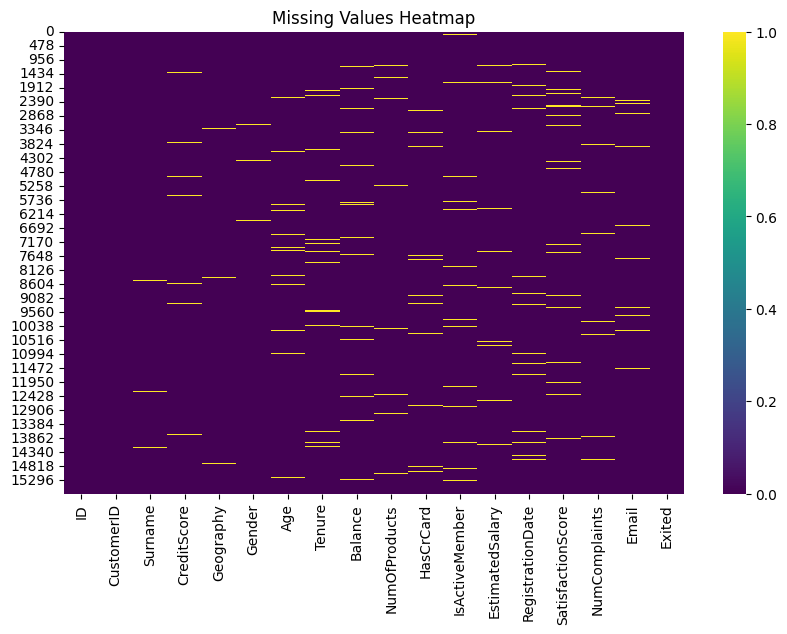

In [8]:
missing = df.isna()
plt.figure(figsize=(10,6))
sns.heatmap(missing, annot=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [9]:
df.duplicated().sum()

np.int64(750)

In [10]:
df.nunique().to_frame("Nombre de valeurs uniques")

,Nombre de valeurs uniques
ID,15000
CustomerID,15000
Surname,2358
CreditScore,611
Geography,9
Gender,11
Age,112
Tenure,13
Balance,14450
NumOfProducts,7


## 4. Analyse de la variable cible — Churn

In [11]:
df["Exited"].value_counts(normalize=True).to_frame("Proportion des clients ")

,Proportion des clients
Exited,
0,0.738667
1,0.261333


## 5. Distribution des variables continues univariés

count    15415.000000
mean       652.448784
std        128.524081
min        -50.000000
25%        582.000000
50%        651.000000
75%        719.000000
max       1500.000000
Name: CreditScore, dtype: float64


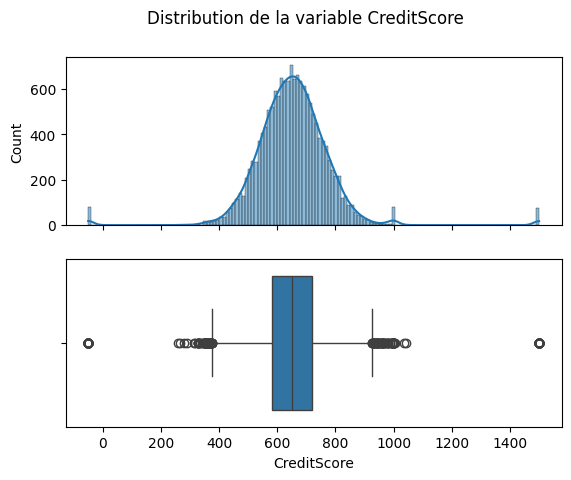

In [12]:
print(df["CreditScore"].describe())

fig, ax = plt.subplots(2,1 ,sharex=True)
plt.suptitle("Distribution de la variable CreditScore")
sns.histplot(df["CreditScore"], ax=ax[0], kde=True)
sns.boxplot(x=df["CreditScore"], ax=ax[1])
plt.show()

count     15270
unique      112
top          42
freq        518
Name: Age, dtype: object


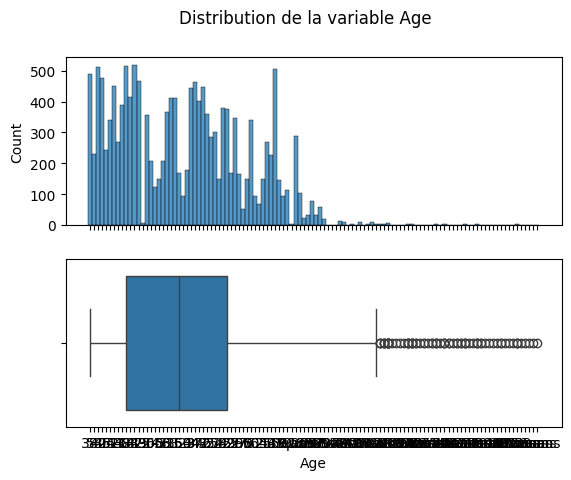

In [13]:
print(df["Age"].describe())
fig, ax = plt.subplots(2,1, sharex=True)
plt.suptitle("Distribution de la variable Age")
sns.histplot(df["Age"], ax=ax[0])
sns.boxplot(x=df["Age"], ax=ax[1])
plt.show()

count    15288.000000
mean         6.008569
std         10.349034
min         -1.000000
25%          2.000000
50%          5.000000
75%          8.000000
max        100.000000
Name: Tenure, dtype: float64


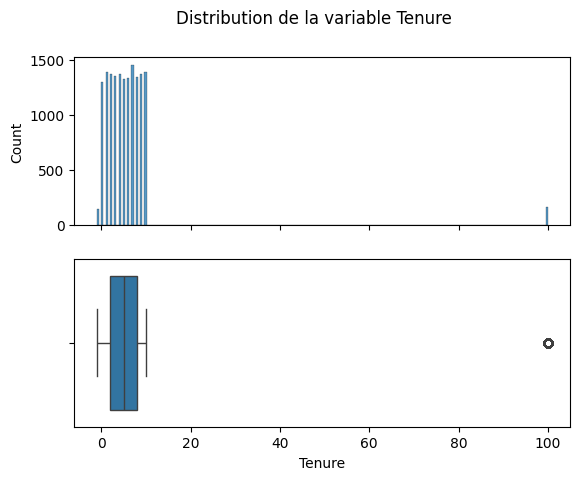

In [14]:
print(df["Tenure"].describe())

fig, ax = plt.subplots(2,1, sharex=True)
plt.suptitle("Distribution de la variable Tenure")
sns.histplot(df["Tenure"],ax=ax[0])
sns.boxplot(x=df["Tenure"], ax=ax[1])
plt.show()


count     15270
unique      112
top          42
freq        518
Name: Age, dtype: object


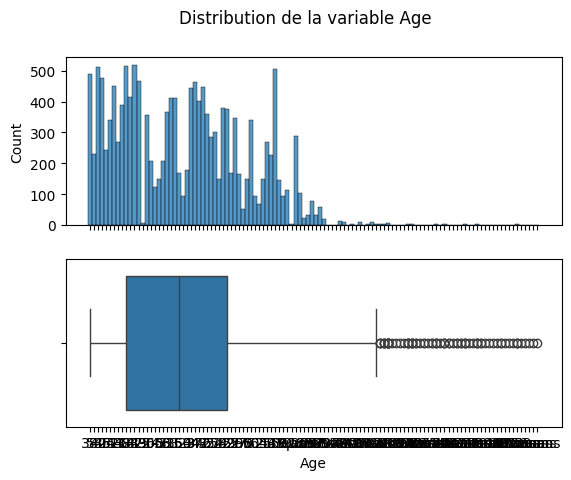

In [15]:
print(df["Age"].describe())

fig, ax = plt.subplots(2,1, sharex=True)
plt.suptitle("Distribution de la variable Age")
sns.histplot(df["Age"], ax=ax[0])
sns.boxplot(x=df["Age"], ax=ax[1])
plt.show()

## 6. Distribution des variables discrètes univariés


NumOfProducts
 1.0     6843
 2.0     5990
 3.0     1582
 4.0      772
-1.0       95
 10.0      76
 0.0       68
Name: count, dtype: int64


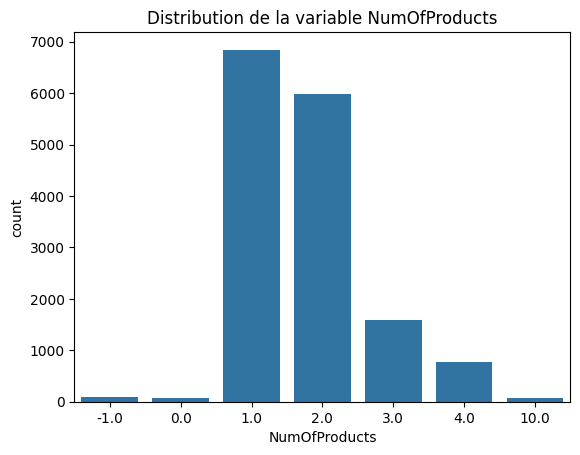

In [24]:
print(df["NumOfProducts"].value_counts())
sns.countplot(x=df["NumOfProducts"])
plt.title("Distribution de la variable NumOfProducts")
plt.show()

RegistrationDate
date inconnue    165
30/02/2014        14
30/02/2011        14
30/02/2010        13
2018-12-08        13
                ... 
23/5/2015          1
2015-07-11         1
2014-01-03         1
2010-06-16         1
2017-05-02         1
Name: count, Length: 5045, dtype: int64


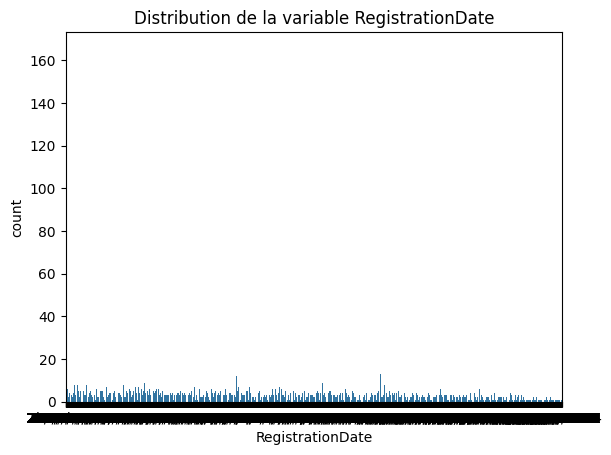

In [23]:
print(df["RegistrationDate"].value_counts())
sns.countplot(x=df["RegistrationDate"])
plt.title("Distribution de la variable RegistrationDate")
plt.show()

SatisfactionScore
3      2829
5      2821
1      2817
2      2769
4      2682
-1      313
10      303
0       291
5/5      71
1/5      67
2/5      67
4/5      64
3/5      56
Name: count, dtype: int64


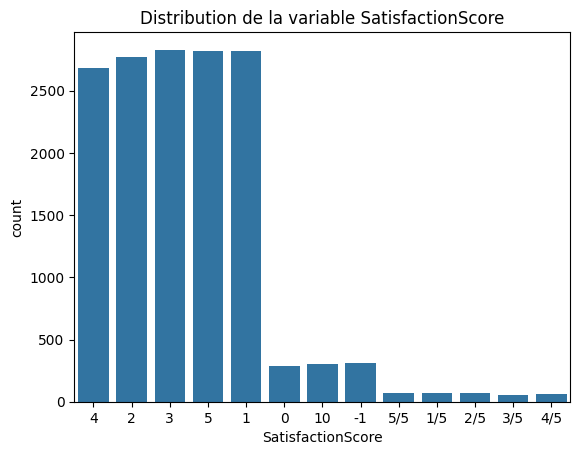

In [22]:
print(df["SatisfactionScore"].value_counts())
sns.countplot(x=df["SatisfactionScore"])
plt.title("Distribution de la variable SatisfactionScore")
plt.show()

NumComplaints
 0.0      7506
 1.0      3770
 2.0      1723
 3.0      1016
 4.0       601
 5.0       313
-1.0       183
 999.0     158
Name: count, dtype: int64


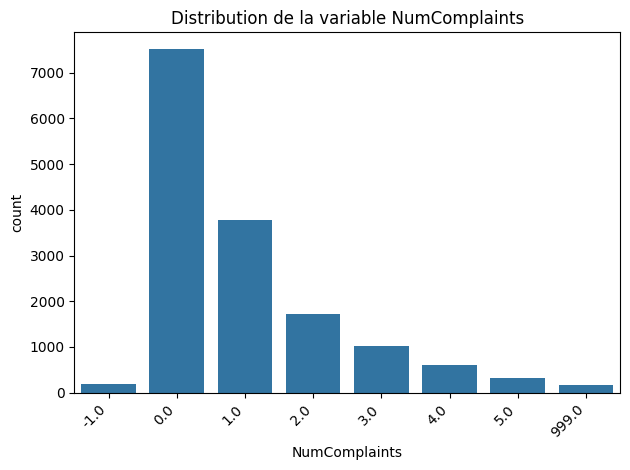

In [49]:
print(df["NumComplaints"].value_counts())
sns.countplot(x=df["NumComplaints"])
plt.title("Distribution de la variable NumComplaints")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 7. Distribution des variables  BINAIRES

HasCrCard
1        7247
0        7131
Non       175
True      166
No        156
Oui       154
False     149
2         134
Yes       130
Name: count, dtype: int64


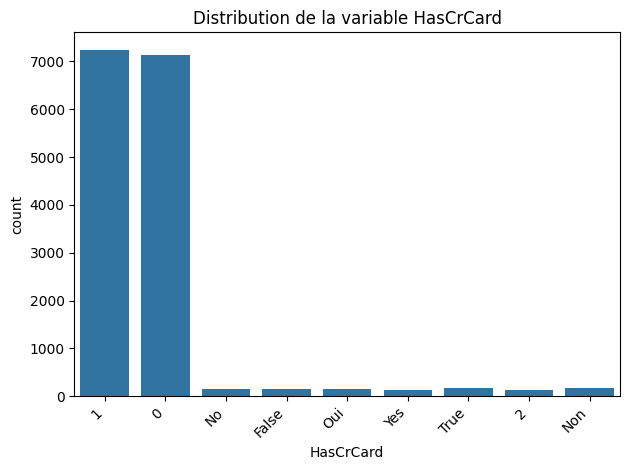

In [48]:
print(df["HasCrCard"].value_counts())
sns.countplot(x=df["HasCrCard"])
plt.title("Distribution de la variable HasCrCard")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

IsActiveMember
1           7324
0           7253
active       186
inactive     178
Y            168
N            157
Name: count, dtype: int64


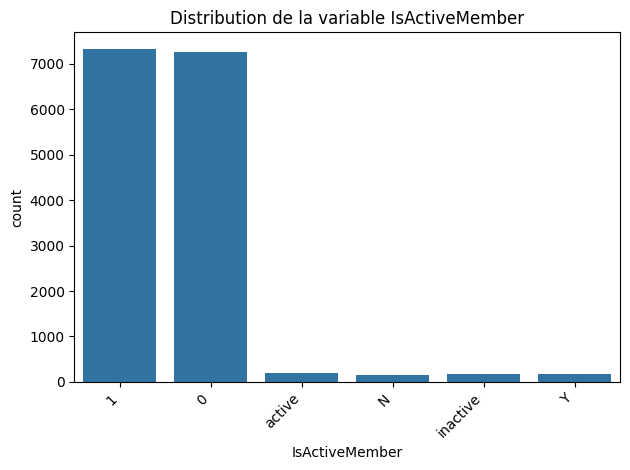

In [47]:
print(df["IsActiveMember"].value_counts())
sns.countplot(x=df["IsActiveMember"])
plt.title("Distribution de la variable IsActiveMember")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. Distribution des variables CATEGORIELLES

Gender
Male       8659
Female     4639
MALE        380
female      336
Femme       329
Homme       315
M           302
F           289
Unknown     163
0           120
1            57
Name: count, dtype: int64


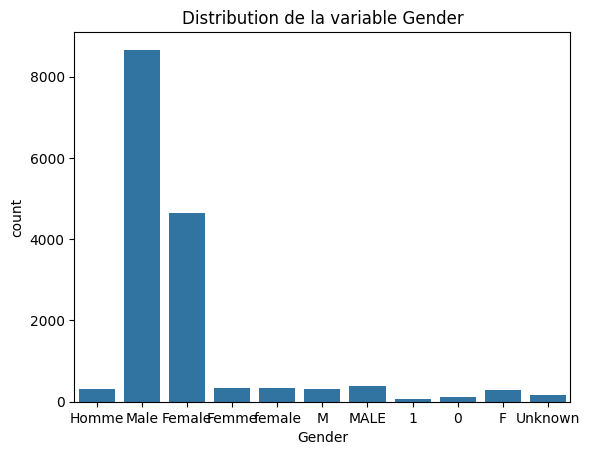

In [33]:
print(df["Gender"].value_counts())
sns.countplot(x=df["Gender"])
plt.title("Distribution de la variable Gender")
plt.show()

Geography
Germany      4892
Spain        4863
France       4663
GERMANY       331
france        305
Espagne       179
Allemagne     146
Frnace        140
?              75
Name: count, dtype: int64


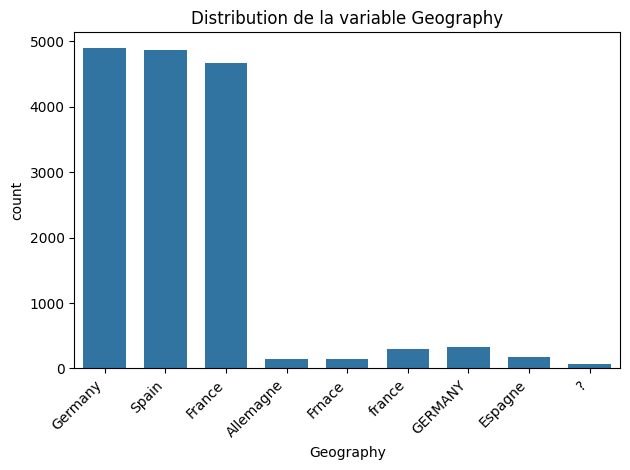

In [46]:
print(df['Geography'].value_counts())
sns.countplot(x=df["Geography"], width=0.7)
plt.title("Distribution de la variable Geography")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 9. Distribution de la  variable Cible

Exited
0    11634
1     4116
Name: count, dtype: int64


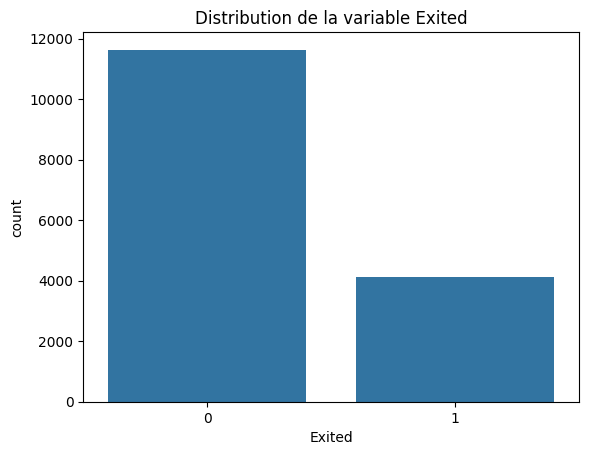

In [36]:
print(df["Exited"].value_counts())
sns.countplot(x=df["Exited"])
plt.title("Distribution de la variable Exited")
plt.show()

## 9. Analyse de la Correlation entre les variables

In [54]:
cols_a_convertir = ["CreditScore", "Age", "Tenure", "Balance", 
                    "EstimatedSalary", "NumOfProducts",
                    "SatisfactionScore", "NumComplaints",
                    "HasCrCard", "IsActiveMember", "Exited"]

df_corr = df[cols_a_convertir].apply(pd.to_numeric, errors="coerce")
print(df_corr.dtypes)

CreditScore          float64
Age                  float64
Tenure               float64
Balance              float64
EstimatedSalary      float64
NumOfProducts        float64
SatisfactionScore    float64
NumComplaints        float64
HasCrCard            float64
IsActiveMember       float64
Exited                 int64
dtype: object


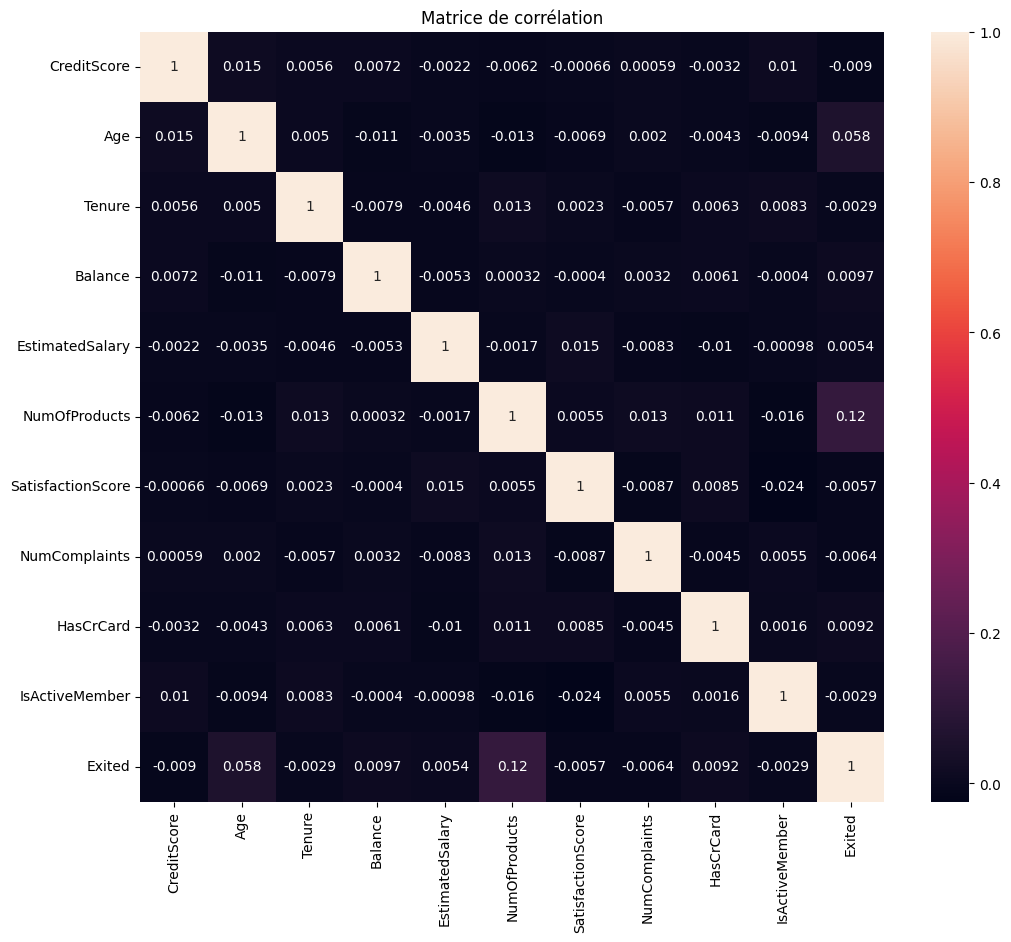

In [56]:
corr_matrix = df_corr.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True)
plt.title("Matrice de corrélation")
plt.show()

## 10. Detection des outliers c'est uniquement sur les variables continues 

In [58]:
variables_continues = ["CreditScore", "Age", "Balance", "EstimatedSalary"]

In [60]:
q1 = df["CreditScore"].quantile(0.25)
q3 = df["CreditScore"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr
print(f"limite inferieure : {lower_bound}, limite superieure : {upper_bound}")

limite inferieure : 376.5, limite superieure : 924.5


In [62]:
q1 = df_corr['Age'].quantile(0.25)
q3 = df_corr['Age'].quantile(0.75)
iqr= q3 - q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr
print(f"limite inferieure : {lower_bound}, limite superieure : {upper_bound}")

limite inferieure : 5.5, limite superieure : 73.5


In [63]:
q1 = df_corr['Balance'].quantile(0.25)
q3 = df_corr['Balance'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr
print(f"limite inferieure : {lower_bound}, limite superieure : {upper_bound}")

limite inferieure : -75912.17249999999, limite superieure : 209054.64749999996


In [65]:
q1 = df_corr["EstimatedSalary"].quantile(0.25)
q3 = df_corr["EstimatedSalary"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5*iqr          
upper_bound = q3 + 1.5*iqr
print(f"limite inferieure : {lower_bound}, limite superieure : {upper_bound}")

limite inferieure : -37508.297499999986, limite superieure : 236792.16249999998


In [69]:
for col in ["Balance", "EstimatedSalary"]:
    q1 = df_corr[col].quantile(0.25)
    q3 = df_corr[col].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr


    nb_outliers = (df_corr[col] > upper_bound).sum()
    print(f"{col} : outliers au-dessus de {upper_bound:.0f} : {nb_outliers}")

Balance : outliers au-dessus de 209055 : 175
EstimatedSalary : outliers au-dessus de 236792 : 117


# 10. Conclusions Générales — EDA ChurnGuard

---

## Vue d'ensemble du dataset

- Nombre de lignes : 15 750
- Nombre de colonnes : 18
- Doublons : 750 (4.76%)
- Taux de churn (Exited=1) : 26.1%
- Mémoire utilisée : 2.2 MB

Le dataset est **déséquilibré** (74% non-churn / 26% churn).
Stratégie prévue : `class_weight='balanced'` ou `SMOTE`

---

## Problèmes critiques détectés

### Encodages incohérents

**Gender** : Male, MALE, M, Homme, 1, Female, Femme, F, 0, Unknown
→ Action : Mapping vers `Male` / `Female`

**Geography** : Germany, GERMANY, Allemagne, France, france, Frnace, Spain, Espagne
→ Action : `.str.strip().str.title()` + mapping

**HasCrCard** : 0, 1, Yes, No, True, False, Oui, Non, 2
→ Action : Mapping vers `0` / `1`

**IsActiveMember** : 0, 1, active, inactive, Y, N
→ Action : Mapping vers `0` / `1`

**SatisfactionScore** : 1-5, 5/5, 10, -1
→ Action : Nettoyage + mapping vers `[1, 5]`

---

### Valeurs aberrantes

**CreditScore** : min=-50, max=1500 (plage normale 300-850)
→ Action : Clipping `[300, 850]`

**Balance** : valeurs jusqu'à 1 milliard
→ Action : Winsorizing borne sup 209 055

**EstimatedSalary** : valeurs jusqu'à 10 millions
→ Action : Winsorizing borne sup 236 792

**Tenure** : valeur aberrante = 100
→ Action : Remplacer par NaN + imputation médiane

**NumOfProducts** : valeurs -1 et 10 impossibles
→ Action : Supprimer ces lignes

**NumComplaints** : valeur 999 impossible
→ Action : Remplacer par NaN + imputation médiane

---

### Dtype incorrect

**Age** : dtype `object` au lieu de `int64` (valeurs texte mélangées)
→ Action : `pd.to_numeric(errors='coerce')` + imputation médiane

**Balance** : dtype `object` au lieu de `float64`
→ Action : `pd.to_numeric(errors='coerce')`

**EstimatedSalary** : dtype `object` au lieu de `float64`
→ Action : `pd.to_numeric(errors='coerce')`

---

## Valeurs manquantes

**SatisfactionScore** : 3.81% → imputation mode
**IsActiveMember** : 3.07% → imputation mode après nettoyage
**Age** : 3.05% → imputation médiane après conversion
**NumComplaints** : 3.05% → imputation médiane
**Email** : 3.24% → colonne à supprimer (non pertinente pour le modèle)
**CreditScore** : 2.13% → imputation médiane
**Toutes autres** : < 3% → imputation médiane ou mode selon le type

---

## Colonnes à supprimer

**ID**, **CustomerID** : identifiants techniques, aucune valeur prédictive
**Surname**, **Email** : données personnelles, aucune valeur prédictive
**RegistrationDate** : 5045 valeurs uniques, inutilisable brut
→ Option : extraire l'année ou calculer l'ancienneté en jours

---

## Corrélations avec Exited

Toutes les corrélations linéaires sont faibles (< 0.15), probablement dues
aux données corrompues. Les variables les plus prometteuses sont
`NumOfProducts` (0.12) et `Age` (0.058).

Une nouvelle heatmap sera produite après le preprocessing pour
obtenir les corrélations réelles.

